In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/advertising.csv')

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [3]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (200, 4)

Column names:
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [4]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [5]:
df.corr(numeric_only=True)

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


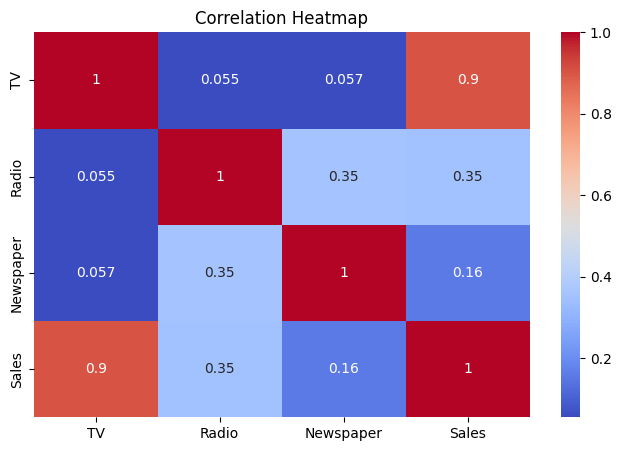

In [6]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

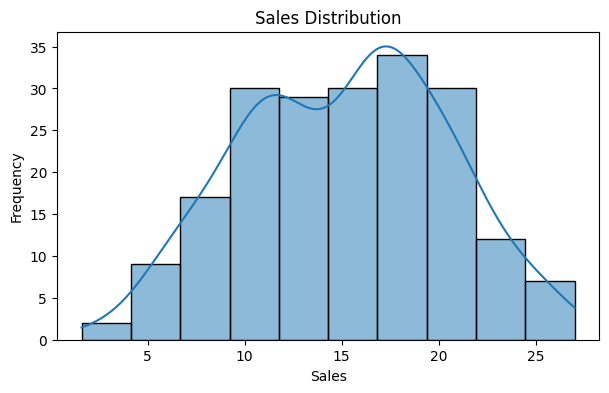

In [7]:
plt.figure(figsize=(7, 4))

sns.histplot(df['Sales'], kde=True)

plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

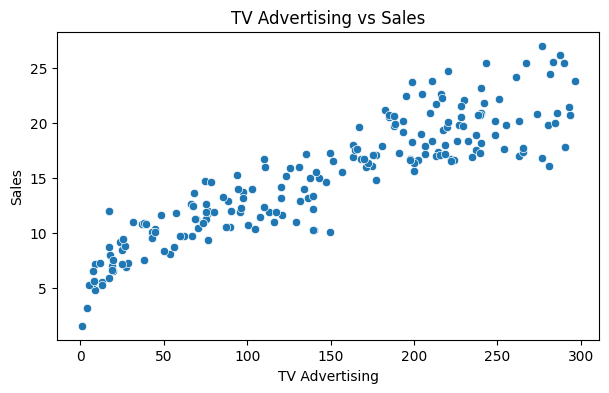

In [8]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title('TV Advertising vs Sales')
plt.xlabel('TV Advertising')
plt.ylabel('Sales')
plt.show()

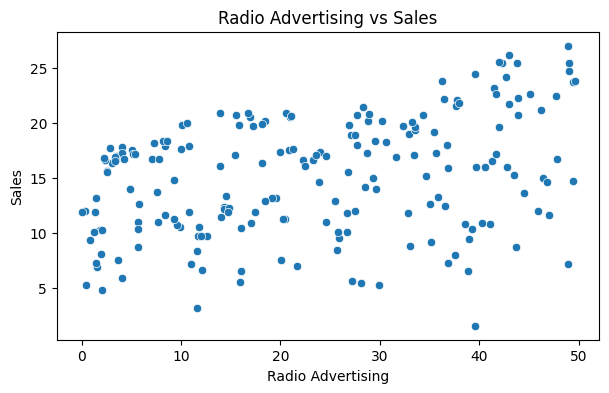

In [9]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title('Radio Advertising vs Sales')
plt.xlabel('Radio Advertising')
plt.ylabel('Sales')
plt.show()

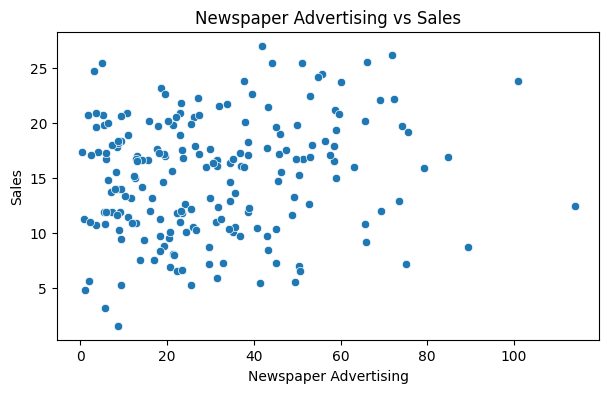

In [10]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Newspaper', y='Sales', data=df)
plt.title('Newspaper Advertising vs Sales')
plt.xlabel('Newspaper Advertising')
plt.ylabel('Sales')
plt.show()

In [11]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target (y):
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [14]:
y_pred = model.predict(X_test)

print("First 10 predicted Sales values:")
print(y_pred[:10])

First 10 predicted Sales values:
[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475]


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.2748262109549338
Mean Squared Error (MSE): 2.9077569102710896
Root Mean Squared Error (RMSE): 1.7052146229349223
R² Score: 0.9059011844150826


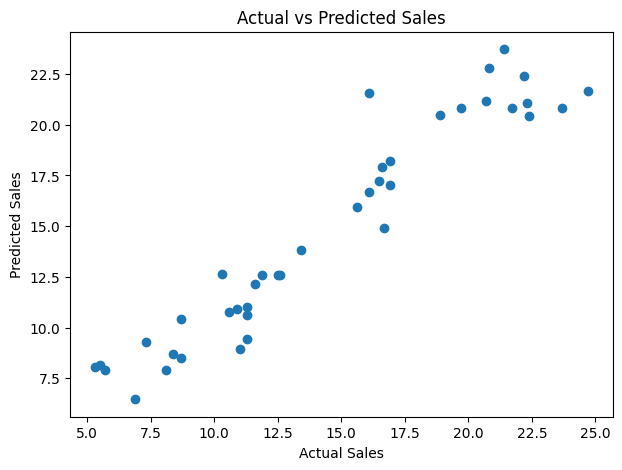

In [16]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

Conclusion:

In this project, a Linear Regression model was developed to predict Sales based on advertising expenditure on TV, Radio, and Newspaper.

The dataset was explored using descriptive statistics, correlation analysis, and visualizations. The data was divided into training and testing sets, and the Linear Regression model was trained using the training data.

The model was evaluated using MAE, MSE, RMSE, and R² Score. The Actual vs Predicted Sales graph was also used to visualize the model's performance.

This project demonstrates how machine learning can be used to analyze the relationship between advertising expenditure and sales and predict future sales.